In [2]:
import shutil
import os

# Define la ruta del archivo que deseas copiar
ruta_origen = '/kaggle/input/progress/loocv_progress (26).json'

# Define la ruta del directorio de destino
ruta_destino = '/kaggle/working/'

# Crea el directorio de destino si no existe
os.makedirs(ruta_destino, exist_ok=True)

# Define el nuevo nombre del archivo
nuevo_nombre = 'loocv_progress.json'

# Copia el archivo al directorio de destino con el nuevo nombre
shutil.copy(ruta_origen, os.path.join(ruta_destino, nuevo_nombre))

print("Archivo copiado y renombrado con éxito.")


Archivo copiado y renombrado con éxito.


2025-07-19 20:45:27.727207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752957928.083618   16450 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752957928.185742   16450 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Cargando todas las imágenes para LOOCV...
Cargando imágenes de /kaggle/input/psoriasis-ds/dataset_v8/dataset_v8...
Total de imágenes cargadas: 798
Progreso cargado. Reanudando desde el fold 780.

Iniciando/Reanudando LOOCV (798 iteraciones)...
Saltando folds hasta el 780...

Procesando Fold LOOCV 780/798
Balanceando 797 muestras de entrenamiento...


I0000 00:00:1752957950.901843   16450 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752957950.902542   16450 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1752957974.637491   16487 service.cc:148] XLA service 0x79941c0d2700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752957974.639040   16487 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752957974.639072   16487 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752957976.815902   16487 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1752957988.365375   16487 device_compiler.h:188] Compiled clust

  Fold 780: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 781/798
Balanceando 797 muestras de entrenamiento...
  Fold 781: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 782/798
Balanceando 797 muestras de entrenamiento...
  Fold 782: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 783/798
Balanceando 797 muestras de entrenamiento...
  Fold 783: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 784/798
Balanceando 797 muestras de entrenamiento...
  Fold 784: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 785/798
Balanceando 797 muestras de entrenamiento...
  Fold 785: Verdadera='Psoriasis Vulgar', Predicha='Psoriasis Vulgar'. Accuracy: 1.0

Procesando Fold LOOCV 786/798
Balanceando 797 muestras de entrenamiento...
  Fold 786: Verdadera='Psoriasis V

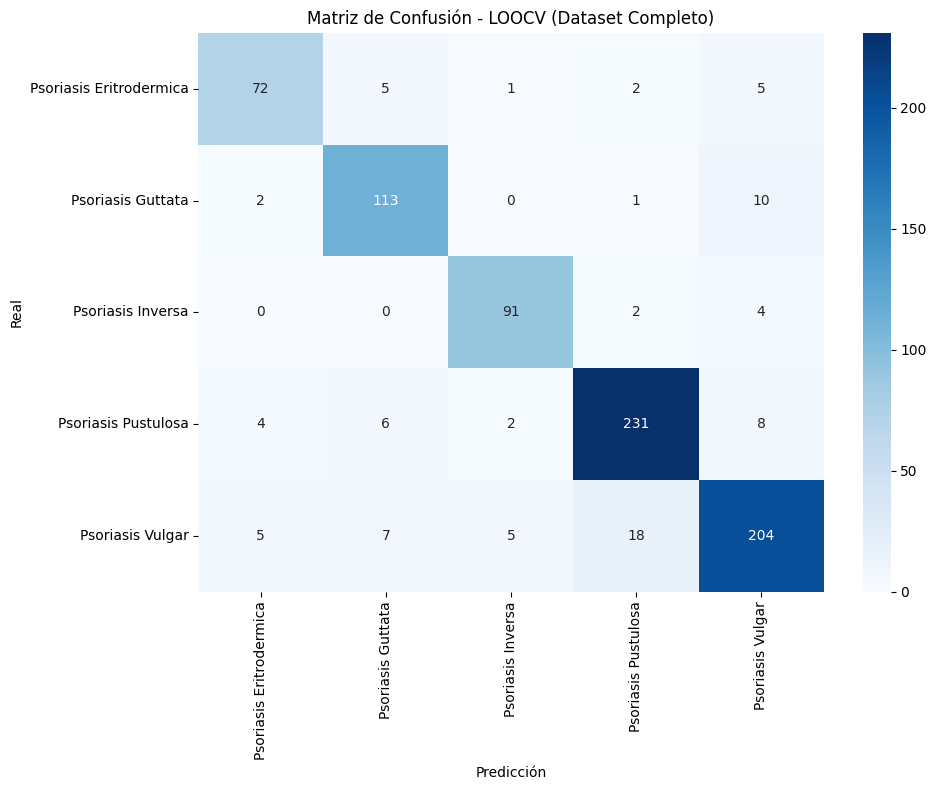

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras import models
from collections import Counter
import gc
import json

# --- Configuración General ---
DATASET_PATH = '/kaggle/input/psoriasis-ds/dataset_v8/dataset_v8'
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS_LOOCV = 5 
RANDOM_SEED = 45
LEARNING_RATE = 0.001

# --- Fichero de Estado para Guardar/Reanudar ---
PROGRESS_FILE = '/kaggle/working/loocv_progress.json'

# --- Funciones de Utilidad ---

def load_all_images(directory, img_size):
    """Carga y preprocesa todas las imágenes de un directorio."""
    classes = sorted(os.listdir(directory))
    images, labels = [], []
    class_indices = {class_name: i for i, class_name in enumerate(classes)}
    print(f"Cargando imágenes de {directory}...")
    for class_name in classes:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path): continue
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
                    img_array = tf.keras.preprocessing.image.img_to_array(img)
                    img_array = preprocess_input(img_array)
                    images.append(img_array)
                    labels.append(class_indices[class_name])
                except Exception as e:
                    print(f"Error cargando imagen {img_path}: {e}")
    return np.array(images), np.array(labels), classes

def balance_dataset_with_augmentation(X_data, y_data, class_names_list):
    """Balancea el dataset de entrenamiento usando data augmentation."""
    print(f"Balanceando {len(X_data)} muestras de entrenamiento...")
    datagen = ImageDataGenerator(
        rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
        shear_range=0.2, zoom_range=0.3, horizontal_flip=True, fill_mode='nearest'
    )
    class_counts = Counter(y_data)
    if not class_counts: return np.array([]), tf.keras.utils.to_categorical(np.array([]), num_classes=len(class_names_list))

    max_count = max(class_counts.values())
    X_balanced, y_balanced = list(X_data), list(y_data)

    for class_idx in range(len(class_names_list)):
        current_indices = np.where(y_data == class_idx)[0]
        current_count = len(current_indices)
        if 0 < current_count < max_count:
            needed = max_count - current_count
            images_to_augment = X_data[current_indices]
            augmented_count = 0
            idx_img_to_augment = 0
            while augmented_count < needed:
                img_original = images_to_augment[idx_img_to_augment % len(images_to_augment)]
                img = np.expand_dims(img_original, 0)
                batch = next(datagen.flow(img, batch_size=1))
                X_balanced.append(batch[0])
                y_balanced.append(class_idx)
                augmented_count += 1
                idx_img_to_augment +=1
    return np.array(X_balanced), tf.keras.utils.to_categorical(np.array(y_balanced), num_classes=len(class_names_list))

def create_efficientnet_model_frozen_base(input_shape, num_classes_model):
    """Crea el modelo EfficientNetB0 con la base congelada y el clasificador personalizado."""
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes_model, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- Pipeline Principal ---

print("Cargando todas las imágenes para LOOCV...")
X_all, y_all, class_names = load_all_images(DATASET_PATH, IMG_SIZE)
if X_all.size == 0: raise ValueError("No se cargaron imágenes.")
num_classes = len(class_names)
total_samples = len(X_all)
print(f"Total de imágenes cargadas: {total_samples}")

# Cargar progreso si existe
start_fold_idx = 0
all_true_labels_loo, all_pred_labels_loo, fold_accuracies_loo = [], [], []
if os.path.exists(PROGRESS_FILE):
    try:
        with open(PROGRESS_FILE, 'r') as f:
            progress_data = json.load(f)
        start_fold_idx = progress_data.get('next_fold_idx', 0)
        all_true_labels_loo = progress_data.get('true_labels', [])
        all_pred_labels_loo = progress_data.get('pred_labels', [])
        fold_accuracies_loo = progress_data.get('fold_accuracies', [])
        print(f"Progreso cargado. Reanudando desde el fold {start_fold_idx + 1}.")
    except Exception as e:
        print(f"Error cargando progreso: {e}. Empezando desde cero.")
        start_fold_idx = 0
else:
    print("No se encontró archivo de progreso. Empezando desde cero.")

# Bucle LOOCV
loo = LeaveOneOut()
if start_fold_idx < total_samples:
    print(f"\nIniciando/Reanudando LOOCV ({total_samples} iteraciones)...")
    for current_run_idx, (train_indices, val_indices) in enumerate(loo.split(X_all)):
        fold_idx = current_run_idx
        if fold_idx < start_fold_idx:
            if fold_idx == 0: print(f"Saltando folds hasta el {start_fold_idx + 1}...")
            continue

        print(f"\nProcesando Fold LOOCV {fold_idx + 1}/{total_samples}")
        X_train_loo, X_val_loo = X_all[train_indices], X_all[val_indices]
        y_train_loo, y_val_loo = y_all[train_indices], y_all[val_indices]

        X_train_loo_balanced, y_train_loo_balanced_categorical = balance_dataset_with_augmentation(
            X_train_loo, y_train_loo, class_names
        )

        if X_train_loo_balanced.size == 0:
            print(f"Fold {fold_idx + 1} saltado: no hay datos de entrenamiento.")
            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(-1)
            fold_accuracies_loo.append(0.0)
        else:
            model_loo = create_efficientnet_model_frozen_base((IMG_SIZE, IMG_SIZE, 3), num_classes)
            model_loo.fit(
                X_train_loo_balanced, y_train_loo_balanced_categorical,
                epochs=EPOCHS_LOOCV, batch_size=BATCH_SIZE, verbose=0
            )
            y_pred_prob_fold = model_loo.predict(X_val_loo, verbose=0)
            y_pred_class_fold = np.argmax(y_pred_prob_fold, axis=1)[0]

            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(int(y_pred_class_fold))
            accuracy_this_fold = 1.0 if y_pred_class_fold == y_val_loo[0] else 0.0
            fold_accuracies_loo.append(accuracy_this_fold)
            print(f"  Fold {fold_idx + 1}: Verdadera='{class_names[y_val_loo[0]]}', Predicha='{class_names[y_pred_class_fold]}'. Accuracy: {accuracy_this_fold}")
            
            del model_loo
            tf.keras.backend.clear_session()
            gc.collect()

        # Guardar progreso después de cada fold
        progress_data_to_save = {
            'next_fold_idx': fold_idx + 1,
            'true_labels': all_true_labels_loo,
            'pred_labels': all_pred_labels_loo,
            'fold_accuracies': fold_accuracies_loo
        }
        try:
            with open(PROGRESS_FILE, 'w') as f:
                json.dump(progress_data_to_save, f, indent=4)
        except Exception as e:
            print(f"    Error guardando progreso: {e}")

# --- Análisis de Resultados Finales de LOOCV ---
print("\n--- Resultados Finales de LOOCV ---")
if all_true_labels_loo:
    valid_indices = [i for i, pred in enumerate(all_pred_labels_loo) if pred != -1]
    y_true_filtered = np.array(all_true_labels_loo)[valid_indices]
    y_pred_filtered = np.array(all_pred_labels_loo)[valid_indices]
    
    mean_loocv_accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    print(f"\nPrecisión Promedio Final de LOOCV: {mean_loocv_accuracy:.2%}")

    print("\nInforme de Clasificación - LOOCV:")
    print(classification_report(y_true_filtered, y_pred_filtered, labels=np.arange(num_classes), target_names=class_names, zero_division=0))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=np.arange(num_classes))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión - LOOCV (Dataset Completo)')
    plt.xlabel('Predicción'); plt.ylabel('Real')
    plt.tight_layout()
    plt.savefig("/kaggle/working/matriz_confusion_loocv_final.jpg", dpi=300)
    plt.show()
else:
    print("No hay resultados de LOOCV para analizar.")
